# Fig 04: Validation of the P-case: SSS, aice, and PSL

In [1]:
import os
os.chdir('/glade/work/fengzhu/Projects/paper-OnlinePDA_CESM/notebooks')
import numpy as np
import pandas as pd
import xarray as xr
import x4c
import datetime
print(f'Last update: {datetime.date.today()}')

Last update: 2026-06-12


## Load Data

In [2]:
case = 'ppe_400ppm'
tags = ['1xCO2', '350ppm', '490ppm', '2xCO2']
vns  = ['SSS', 'aice', 'PSL']

fd = {vn: {} for vn in vns}
for vn in vns:
    da = {}
    for tag in tags + ['400ppm']:
        da[tag] = xr.open_dataarray(f'../sims/da_{vn}_{tag}.nc').mean('time').x.regrid()
    fd[vn]['Truth'] = da['400ppm']
    fd[vn]['Prior'] = (da['1xCO2'] + da['350ppm'] + da['490ppm'] + da['2xCO2']) / 4


In [3]:
recon = xr.open_dataset(f'../recons/recon_Plio400ppm_R0.01_loc10000.nc')

fd['SSS']['Offline'] = recon['SALT'].isel(z_t=0).mean(('time', 'ens')).x.regrid()
fd['SSS']['Offline'].name = 'SSS'

fd['aice']['Offline'] = recon['aice'].mean(('time', 'ens')).rename({'TLONG': 'TLON', 'ULONG': 'ULON'}).x.regrid()
fd['aice']['Offline'].name = 'aice'

fd['PSL']['Offline'] = recon['PSL'].mean(('time', 'ens')).x.regrid()
fd['PSL']['Offline'].name = 'PSL'


In [4]:
for vn in vns:
    da = {}
    for tag in tags:
        da[tag] = xr.open_dataarray(f'../sims/da_{vn}_{tag}_{case}_fixed.nc').mean('time').x.regrid()
    fd[vn]['Online'] = (da['1xCO2'] + da['350ppm'] + da['490ppm'] + da['2xCO2']) / 4


In [5]:
df = pd.read_json(f'../pseudoproxy/ppe_Plio400ppm_obs_SST_R0.01.json')
ms = 20

## Plotting

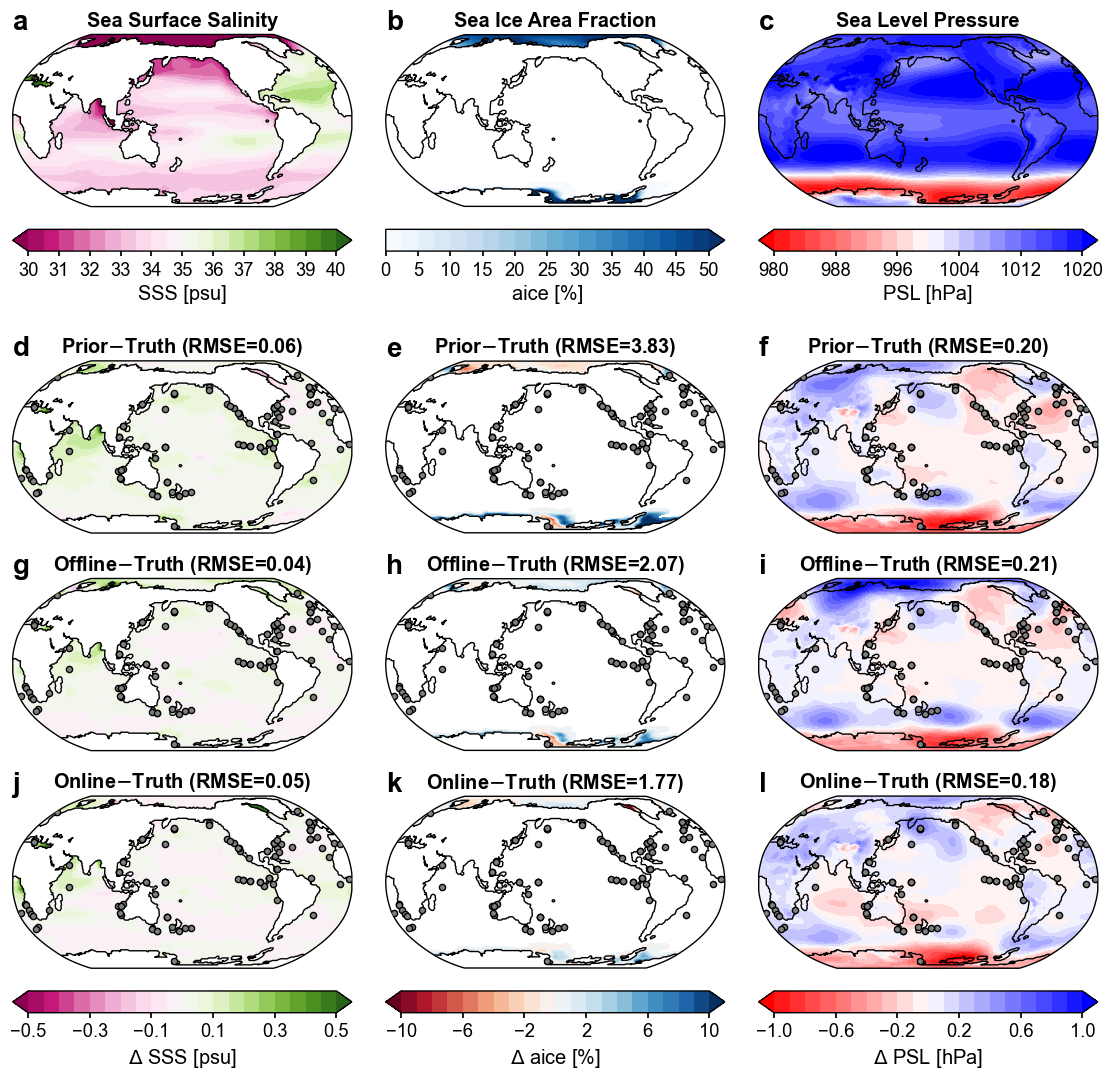

Figure saved at: "../figs/ppe_400ppm_SSS_aice_PSL_maps.pdf"


In [6]:
x4c.set_style('journal', font_scale=1.2)

SST_rgd = xr.open_dataarray('../sims/da_SST_400ppm.nc').mean('time').x.regrid()
ssv = SST_rgd

vars_config = {
    'SSS': {
        'title':       'Sea Surface Salinity',
        'cbar_lb':     'SSS',
        'cmap':        'PiYG',
        'unit':        'psu',
        'scale':       1.0,
        'levels':      np.linspace(30, 40, 21),
        'ticks':       np.linspace(30, 40, 11),
        'diff_levels': np.linspace(-0.5, 0.5, 21),
        'diff_ticks':  np.linspace(-0.5, 0.5, 6),
    },
    'aice': {
        'title':       'Sea Ice Area Fraction',
        'cbar_lb':     'aice',
        'cmap':        'RdBu',
        'unit':        '%',
        'scale':       1.0,
        'levels':      np.linspace(0, 50, 21),
        'ticks':       np.linspace(0, 50, 11),
        'diff_levels': np.linspace(-10, 10, 21),
        'diff_ticks':  np.linspace(-10, 10, 6),
    },
    'PSL': {
        'title':       'Sea Level Pressure',
        'cbar_lb':     'PSL',
        'cmap':        'bwr_r',
        'unit':        'hPa',
        'scale':       0.01,
        'levels':      np.linspace(980, 1020, 21),
        'ticks':       np.linspace(980, 1020, 6),
        'diff_levels': np.linspace(-1, 1, 21),
        'diff_ticks':  np.linspace(-1, 1, 6),
    },
}

vns_plot  = ['SSS', 'aice', 'PSL']
diff_tags = ['Prior', 'Offline', 'Online']

nrow = 46

tag_rows = {
    'Truth':   slice(0,  10),
    'Prior':   slice(15, 25),
    'Offline': slice(25, 35),
    'Online':  slice(35, 45),
}

ax_loc = {}
for tag, row in tag_rows.items():
    for j, vn in enumerate(vns_plot):
        ax_loc[f'{vn}_{tag}'] = (row, j)
for j, vn in enumerate(vns_plot):
    ax_loc[f'cb_{vn}_truth'] = (10, j)
    ax_loc[f'cb_{vn}_diff']  = (45, j)

projs           = {k: 'Robinson' for k in ax_loc if not k.startswith('cb_')}
projs_kws       = {k: {'central_longitude': 180} for k in projs}
annotation_kws  = {k: {'loc_x': 0.0, 'style': ''} for k in projs}
annotation_skip = [k for k in ax_loc if k.startswith('cb_')]

fig, ax = x4c.visual.subplots(
    figsize=(14, 13), nrow=nrow, ncol=3, hspace=0, wspace=0.1,
    ax_loc=ax_loc,
    projs=projs,
    projs_kws=projs_kws,
    annotation=True,
    annotation_separate=True,
    annotation_kws=annotation_kws,
    annotation_skip=annotation_skip,
)

for j, vn in enumerate(vns_plot):
    cfg   = vars_config[vn]
    scale = cfg['scale']

    # aice mask: only show grid cells where truth > 0
    aice_mask = fd['aice']['Truth'] > 0 if vn == 'aice' else None

    # Truth
    extend = 'max' if vn == 'aice' else 'both'
    truth = fd[vn]['Truth'] * scale
    if aice_mask is not None:
        truth = truth.where(aice_mask)
    _, im_truth = truth.x.plot(
        ax=ax[f'{vn}_Truth'],
        ssv=ssv,
        levels=cfg['levels'],
        title=cfg['title'],
        add_colorbar=False,
        return_im=True,
        extend=extend,
    )
    fig.colorbar(im_truth, cax=ax[f'cb_{vn}_truth'],
                 label=f'{cfg["cbar_lb"]} [{cfg["unit"]}]',
                 orientation='horizontal', ticks=cfg['ticks'])

    # Differences
    im_diff = None
    for tag in diff_tags:
        diff = (fd[vn][tag] - fd[vn]['Truth']) * scale
        if aice_mask is not None:
            diff = diff.where(aice_mask)
        lat_rad = np.deg2rad(diff['lat'])
        weights = np.cos(lat_rad).broadcast_like(diff)
        rmse = float(np.sqrt((diff**2).weighted(weights).mean(dim=['lat', 'lon'])))
        _, im = diff.x.plot(
            ax=ax[f'{vn}_{tag}'],
            ssv=ssv,
            levels=cfg['diff_levels'],
            cmap=cfg['cmap'],
            title=fr'{tag}$-$Truth (RMSE={rmse:.2f})',
            add_colorbar=False,
            return_im=True,
            df_sites=df[['lat', 'lon']],
            legend=False,
            site_markersizes=ms,
        )
        if im_diff is None:
            im_diff = im
    fig.colorbar(im_diff, cax=ax[f'cb_{vn}_diff'],
                 label=fr'$\Delta$ {cfg["cbar_lb"]} [{cfg["unit"]}]',
                 orientation='horizontal', ticks=cfg['diff_ticks'])

x4c.showfig(fig)
x4c.savefig(fig, f'../figs/{case}_SSS_aice_PSL_maps.pdf')